In [1]:
import random
import math
import matplotlib.pyplot as plt

In [2]:
locations = {
    "Restaurant": (50, 50),

    "Customer 1": (20, 80),
    "Customer 2": (80, 80),
    "Customer 3": (15, 20),
    "Customer 4": (85, 25),
    "Customer 5": (50, 10),
    "Customer 6": (30, 50),
    "Customer 7": (70, 55)
}

In [3]:
def calculate_distance(point1, point2):
    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [4]:
def route_distance(route):

    total_distance = 0

    for i in range(len(route) - 1):

        current_location = locations[route[i]]
        next_location = locations[route[i + 1]]

        total_distance += calculate_distance(
            current_location,
            next_location
        )

    return total_distance

In [5]:
customers = [
    "Customer 1",
    "Customer 2",
    "Customer 3",
    "Customer 4",
    "Customer 5",
    "Customer 6",
    "Customer 7"
]

In [6]:
def create_route():

    route = customers.copy()

    random.shuffle(route)

    return route

In [7]:
def create_population(population_size):

    population = []

    for _ in range(population_size):

        route = create_route()

        population.append(route)

    return population

In [8]:
population = create_population(10)

for route in population:
    print(route)

['Customer 4', 'Customer 3', 'Customer 5', 'Customer 7', 'Customer 6', 'Customer 1', 'Customer 2']
['Customer 1', 'Customer 4', 'Customer 2', 'Customer 3', 'Customer 5', 'Customer 7', 'Customer 6']
['Customer 7', 'Customer 3', 'Customer 1', 'Customer 4', 'Customer 5', 'Customer 2', 'Customer 6']
['Customer 5', 'Customer 3', 'Customer 7', 'Customer 1', 'Customer 6', 'Customer 4', 'Customer 2']
['Customer 1', 'Customer 3', 'Customer 5', 'Customer 7', 'Customer 2', 'Customer 6', 'Customer 4']
['Customer 4', 'Customer 1', 'Customer 7', 'Customer 5', 'Customer 3', 'Customer 2', 'Customer 6']
['Customer 5', 'Customer 2', 'Customer 7', 'Customer 3', 'Customer 1', 'Customer 6', 'Customer 4']
['Customer 3', 'Customer 4', 'Customer 6', 'Customer 7', 'Customer 5', 'Customer 1', 'Customer 2']
['Customer 4', 'Customer 6', 'Customer 1', 'Customer 7', 'Customer 2', 'Customer 5', 'Customer 3']
['Customer 7', 'Customer 2', 'Customer 6', 'Customer 3', 'Customer 1', 'Customer 5', 'Customer 4']


In [9]:
def selection(population, tournament_size=3):

    selected = random.sample(population, tournament_size)

    selected.sort(key=fitness, reverse=True)

    return selected[0]

In [10]:
def fitness(route):

    complete_route = ["Restaurant"] + route

    distance = route_distance(complete_route)

    return 1 / distance

In [11]:
def selection(population, tournament_size=3):

    selected = random.sample(
        population,
        tournament_size
    )

    selected.sort(
        key=fitness,
        reverse=True
    )

    return selected[0]

In [12]:
def crossover(parent1, parent2):

    start, end = sorted(
        random.sample(range(len(parent1)), 2)
    )

    child = [None] * len(parent1)

    child[start:end] = parent1[start:end]

    remaining = [
        customer
        for customer in parent2
        if customer not in child
    ]

    index = 0

    for i in range(len(child)):

        if child[i] is None:

            child[i] = remaining[index]

            index += 1

    return child

In [13]:
def mutate(route, mutation_rate=0.1):

    route = route.copy()

    if random.random() < mutation_rate:

        index1, index2 = random.sample(
            range(len(route)), 2
        )

        route[index1], route[index2] = \
            route[index2], route[index1]

    return route

In [14]:
def next_generation(population):

    new_population = []

    population_size = len(population)

    for _ in range(population_size):

        parent1 = selection(population)

        parent2 = selection(population)

        child = crossover(parent1, parent2)

        child = mutate(child)

        new_population.append(child)

    return new_population
    

In [15]:
population_size = 100
generations = 200

population = create_population(population_size)

best_routes = []
best_distances = []

for generation in range(generations):

    population = next_generation(population)

    best_route = min(
        population,
        key=lambda route: route_distance(
            ["Restaurant"] + route
        )
    )

    best_distance = route_distance(
        ["Restaurant"] + best_route
    )

    best_routes.append(best_route)

    best_distances.append(best_distance)

    if generation % 20 == 0:

        print(
            f"Generation {generation}: "
            f"{best_distance:.2f}"
        )

Generation 0: 269.58
Generation 20: 265.48
Generation 40: 265.48
Generation 60: 265.48
Generation 80: 265.48
Generation 100: 265.48
Generation 120: 265.48
Generation 140: 265.48
Generation 160: 265.48
Generation 180: 265.48


In [16]:
best_route = min(
    population,
    key=lambda route: route_distance(
        ["Restaurant"] + route
    )
)

complete_route = ["Restaurant"] + best_route

print("Best Route:")

for location in complete_route:
    print(location, end=" → ")

print("\nTotal Distance:",
      round(route_distance(complete_route), 2))

Best Route:
Restaurant → Customer 4 → Customer 5 → Customer 3 → Customer 6 → Customer 1 → Customer 7 → Customer 2 → 
Total Distance: 265.48


In [17]:
def plot_route(route):

    route = ["Restaurant"] + route

    x_values = [
        locations[location][0]
        for location in route
    ]

    y_values = [
        locations[location][1]
        for location in route
    ]

    plt.figure(figsize=(10, 7))

    plt.plot(
        x_values,
        y_values,
        marker="o"
    )

    for location in route:

        x, y = locations[location]

        plt.annotate(
            location,
            (x, y),
            xytext=(5, 5),
            textcoords="offset points"
        )

    plt.title("Optimized Food Delivery Route")

    plt.xlabel("X Coordinate")

    plt.ylabel("Y Coordinate")

    plt.grid(True)

    plt.show()

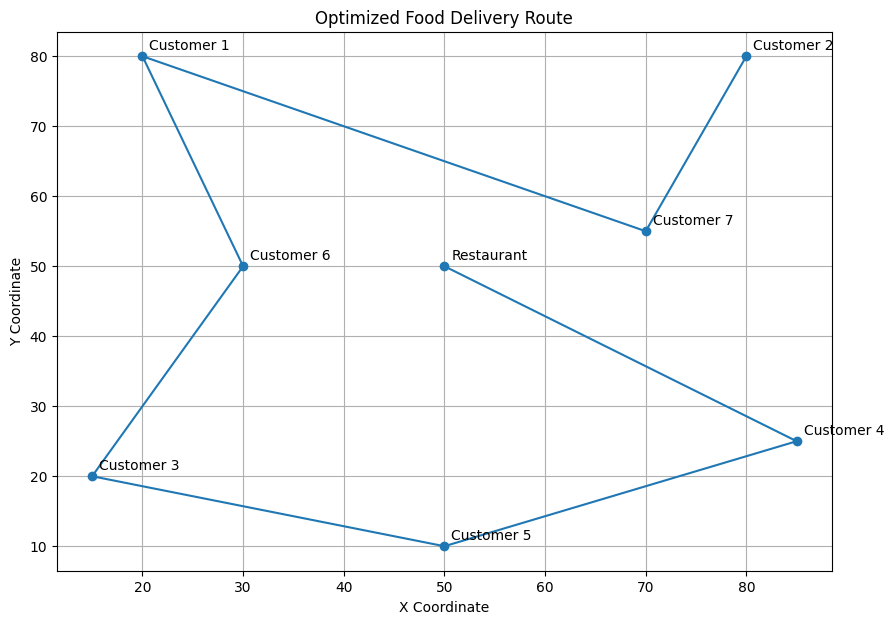

In [18]:
plot_route(best_route)

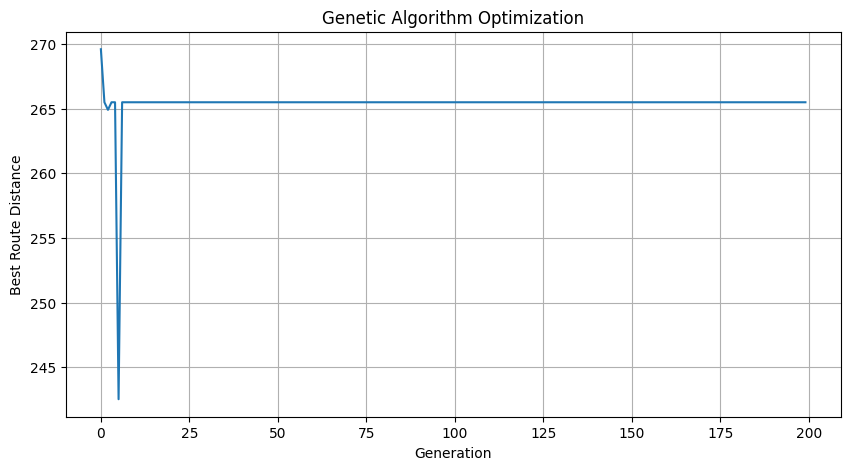

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(best_distances)

plt.xlabel("Generation")

plt.ylabel("Best Route Distance")

plt.title("Genetic Algorithm Optimization")

plt.grid(True)

plt.show()